In [1]:
import rasterio
from rasterio.merge import merge
from rasterio.plot import show
import glob
import matplotlib.pyplot as plt

# List your files (example with 4 specific files)
tif_files = [
    "F:\\Milan_LinkedIn\\GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0_R4_C19\\GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0_R4_C19.tif",
    "F:\\Milan_LinkedIn\\GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0_R4_C20\\GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0_R4_C20.tif",
    "F:\\Milan_LinkedIn\\GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0_R5_C19\\GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0_R5_C19.tif",
    "F:\\Milan_LinkedIn\\GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0_R5_C20\\GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0_R5_C20.tif"
]

# Open all rasters
src_files_to_mosaic = [rasterio.open(fp) for fp in tif_files]

# Merge them
mosaic, out_trans = merge(src_files_to_mosaic)

# Copy the metadata of the first file
out_meta = src_files_to_mosaic[0].meta.copy()

# Update metadata to match new mosaic
out_meta.update({
    "driver": "GTiff",
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_trans,
    "crs": src_files_to_mosaic[0].crs
})

# Save to new file
with rasterio.open("merged.tif", "w", **out_meta) as dest:
    dest.write(mosaic)

# Close the open files
for src in src_files_to_mosaic:
    src.close()

In [4]:
from shapely.geometry import box
from rasterio.mask import mask
import geopandas as gpd

In [5]:
bbox = box(-10.0, 34.0, 40.0, 72.0)
gdf = gpd.GeoDataFrame({'geometry' : bbox}, index = [0], crs = 'EPSG:4326')
gdf

,geometry
0,"POLYGON ((40 34, 40 72, -10 72, -10 34, 40 34))"


In [6]:
gdf.to_file('bbox.geojson', driver = 'GeoJSON')

In [7]:
raster_file = 'merged.tif'

with rasterio.open(raster_file) as src:

    out_image, out_transform = mask(src, gdf.geometry, crop = True)

    out_meta = src.meta.copy()
    out_meta.update({
        'driver' : 'GTiff',
        'height' : out_image.shape[1],
        'width'  : out_image.shape[2],
        'transform' : out_transform
    })

In [8]:
out_meta

{'driver': 'GTiff',
 'dtype': 'float64',
 'nodata': None,
 'width': 2400,
 'height': 2400,
 'count': 1,
 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'),
 'transform': Affine(0.00833333330032682, 0.0, -0.00791664424099281,
        0.0, -0.008333333299795073, 59.09958329838334)}

In [9]:
output_file = 'clipped_raster.tif'

with rasterio.open(output_file, 'w', **out_meta) as dest:
    dest.write(out_image)

In [10]:
with rasterio.open(output_file) as src:
    out_image = src.read(1)
    out_transform = src.transform

In [11]:
import matplotlib.colors as colors

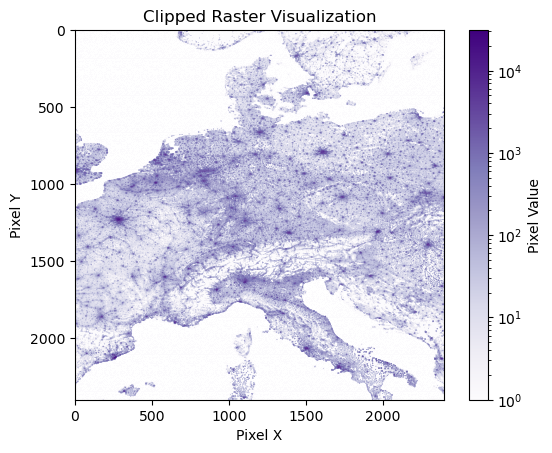

In [12]:
plt.imshow(out_image, 
           cmap = 'Purples',
           norm = colors.LogNorm(vmin=out_image.min() + 1, vmax = out_image.max()))

plt.title('Clipped Raster Visualization')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
plt.colorbar(label = 'Pixel Value')
plt.show()

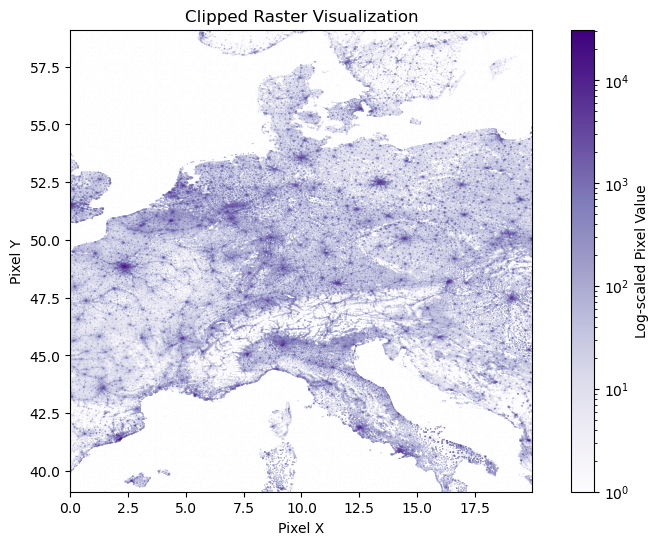

In [13]:
fig, ax = plt.subplots(figsize=(10,6))

img = show(out_image, transform = out_transform, ax = ax, cmap = 'Purples', norm = colors.LogNorm(vmin=out_image.min() + 1, vmax = out_image.max()))

cbar = fig.colorbar(img.get_images()[0], ax = ax, label = 'Log-scaled Pixel Value')

plt.title('Clipped Raster Visualization')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')

plt.show()

<Axes: >

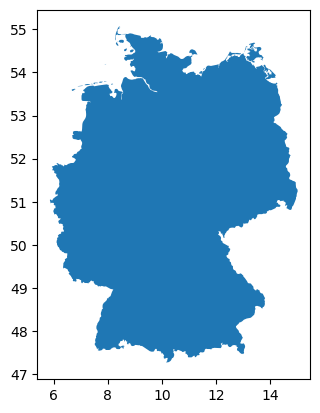

In [14]:
gdf = gpd.read_file('F:\\Milan_LinkedIn\\ne_10m_admin_0_countries')
gdf = gdf[gdf.SOVEREIGNT == 'Germany']
gdf.plot()

In [15]:
input_raster = 'clipped_raster.tif'
output_raster = 'germany_population.tif'

In [16]:
with rasterio.open(input_raster) as src:
    geom = [gdf.geometry.unary_union]
    out_image, out_transform = mask(src, geom, crop = True)

    out_meta = src.meta.copy()
    out_meta.update({
        'driver' : 'GTiff', 
        'height' : out_image.shape[1],
        'width' : out_image.shape[2],
        'transform' : out_transform
    })

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12564\3623937843.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = [gdf.geometry.unary_union]


In [17]:
with rasterio.open(output_raster, 'w', **out_meta) as dest:
    dest.write(out_image)

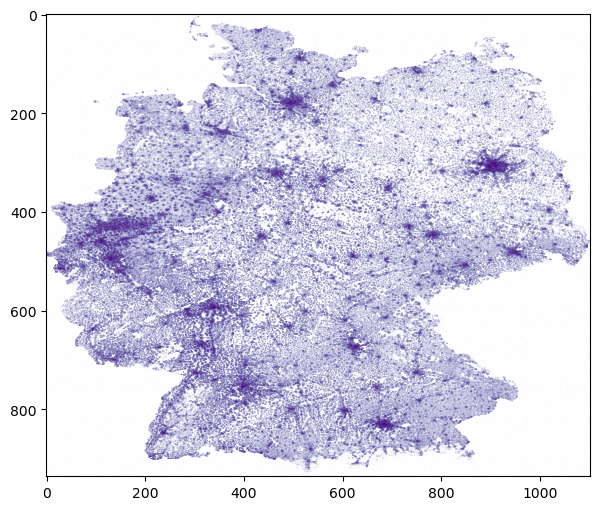

In [18]:
plt.figure(figsize=(10,6))

plt.imshow(out_image[0],
           cmap = 'Purples',
           norm = colors.LogNorm(vmin=out_image.min()+1, vmax = out_image.max()))


Elevation raster data

In [19]:
raster_file = 'F:\\Milan_LinkedIn\\srtm_germany_dsm\\srtm_germany_dsm.tif'

In [20]:
with rasterio.open(raster_file) as src:

    raster_data = src.read(1)

    profile = src.profile
    bounds = src.bounds
    resolution = src.res
    mean_val = raster_data.mean()
    max_val = raster_data.max()
    min_val = raster_data.min()

In [21]:
profile

{'driver': 'GTiff', 'dtype': 'int16', 'nodata': None, 'width': 13201, 'height': 10801, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.0008333333333333333, 0.0, 4.999583333333334,
       0.0, -0.0008333333333333333, 56.000416666666666), 'blockxsize': 13201, 'blockysize': 1, 'tiled': False, 'interleave': 'band'}

In [22]:
bounds

BoundingBox(left=4.999583333333334, bottom=46.999583333333334, right=16.000416666666666, top=56.000416666666666)

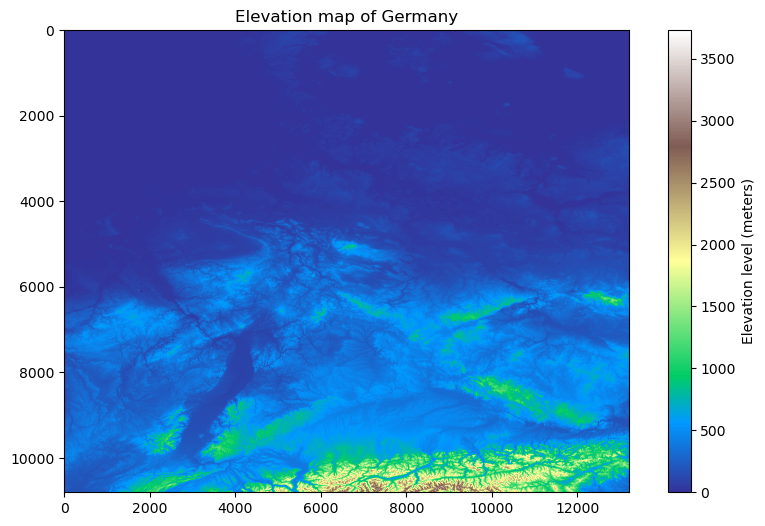

In [23]:
plt.figure(figsize=(10,6))
plt.imshow(raster_data, cmap = 'terrain')
plt.title('Elevation map of Germany')
plt.colorbar(label = 'Elevation level (meters)')

In [24]:
output_file = 'germany_elevation.tif'

In [25]:
with rasterio.open(raster_file) as src:
    geom = [gdf.geometry.unary_union]
    out_image, out_transform = mask(src, geom, crop = True)
    out_meta = src.meta.copy()
    out_meta.update({
        'drive' : 'GTiff',
        'height' : out_image.shape[1],
        'width' : out_image.shape[2],
        'transform' : out_transform
    })

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12564\1787654239.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = [gdf.geometry.unary_union]


In [26]:
with rasterio.open(output_file, 'w', **out_meta) as dest:
    dest.write(out_image)

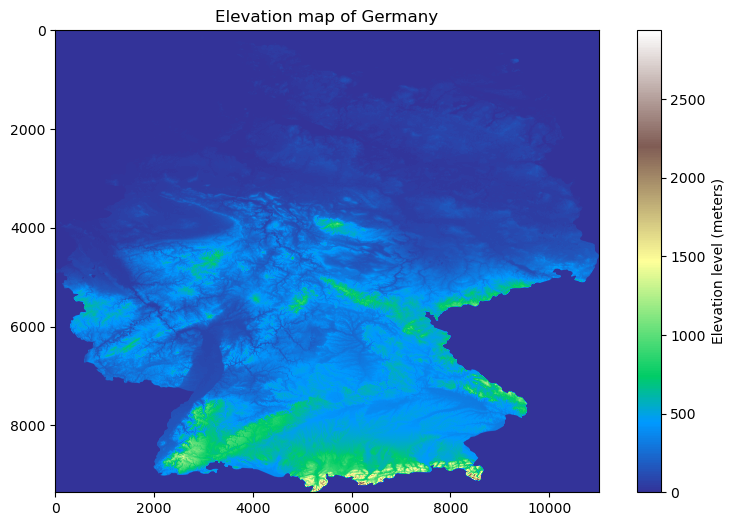

In [27]:
plt.figure(figsize=(10,6))
plt.imshow(out_image[0], 
           cmap = 'terrain')
plt.title('Elevation map of Germany')
plt.colorbar(label = 'Elevation level (meters)')